In [48]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
import numpy as np

In [49]:
df1 = pd.read_csv("../data/total/ssm_all_features.csv")
df2 = pd.read_csv("../data/total/features_before_selection2.csv")

In [50]:
joined_df= pd.merge(df1, df2, on=["conv_id", "turn_id"], how="inner")

In [51]:
assert len(joined_df) == len(df1) == len(df2)
assert (joined_df["y"]==joined_df["label"]).all()

In [52]:
vector_list= list(str(col) for col in range(768+768))

In [53]:
vector_df= joined_df[vector_list]
feature_df= joined_df.drop(columns=vector_list+["label","y"])
y= joined_df["y"]

In [54]:
feature_df.columns

Index(['state_drift', 'state_input_distance', 'long_term_state_drift',
       'state_similarity', 'state_input_similarity',
       'long_term_state_similarity', 'conv_id', 'turn_id', 'toxicity_score',
       'threat_score', 'topic_drift_score', 'drift_acceleration',
       'interaction_risk', 'pattern_risk', 'progressive_risk',
       'prev_progressive', 'toxicity_score_ema3',
       'toxicity_score_rolling3_mean', 'toxicity_score_rolling3_max',
       'threat_score_ema3', 'threat_score_rolling3_mean',
       'threat_score_rolling3_max', 'interaction_risk_ema3',
       'interaction_risk_rolling3_mean', 'interaction_risk_rolling3_max',
       'pattern_risk_ema3', 'pattern_risk_rolling3_mean',
       'pattern_risk_rolling3_max', 'toxicity_diff', 'threat_diff',
       'toxicity_accel', 'risk_slope_3', 'max_toxicity_so_far',
       'max_threat_so_far', 'mean_risk_so_far', 'early_high_risk',
       'late_risk_increase', 'risk_growth_ratio'],
      dtype='object')

In [55]:
train_vectors, test_vectors, train_features, test_features, train_labels, test_labels = train_test_split(
    vector_df, feature_df, y, test_size=0.1, random_state=42
)

train_vectors,val_vectors, train_features, val_features, train_labels, val_labels = train_test_split(
    train_vectors, train_features, train_labels, test_size=0.1, random_state=42
)   

In [56]:
# train_df= pd.concat([train_vectors, train_features, train_labels], axis=1)
# val_df= pd.concat([val_vectors, val_features, val_labels], axis=1)
# test_df= pd.concat([test_vectors, test_features, test_labels], axis=1)
# print(train_df.shape, val_df.shape, test_df.shape)

# train_df.to_csv("../data/merged/train_df.csv", index=False)
# val_df.to_csv("../data/merged/val_df.csv", index=False)
# test_df.to_csv("../data/merged/test_df.csv", index=False)

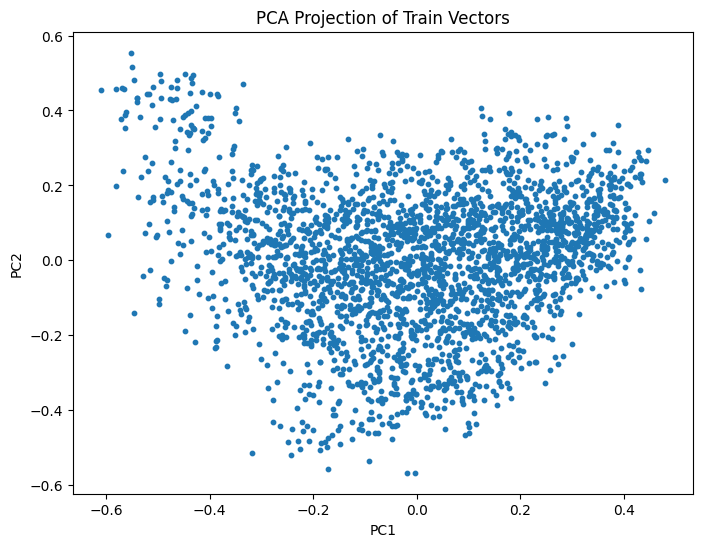

In [57]:
pca = PCA(n_components=2)   
reduced = pca.fit_transform(train_vectors)

plt.figure(figsize=(8,6))
plt.scatter(reduced[:, 0], reduced[:, 1], s=10)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA Projection of Train Vectors")
plt.show()

In [58]:
pca = PCA()
pca.fit(train_vectors)
explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

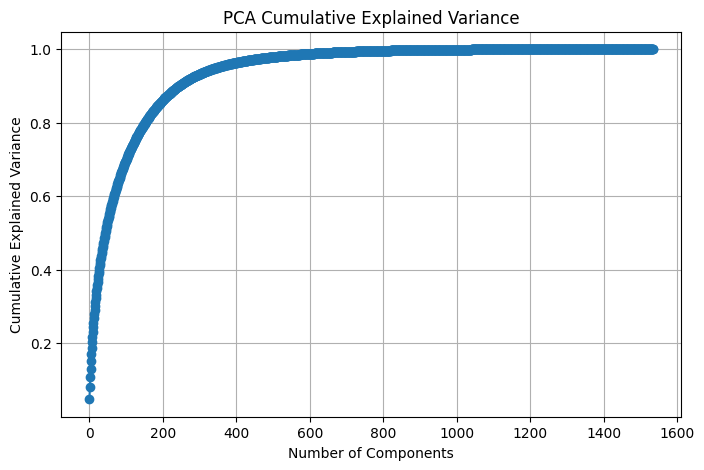

In [59]:
plt.figure(figsize=(8,5))
plt.plot(cumulative_variance, marker='o')
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Cumulative Explained Variance")
plt.grid(True)
plt.show()

In [60]:
pca = PCA(n_components=0.95)  
train_pca = pca.fit_transform(train_vectors)

print("Original dims:", train_vectors.shape[1])
print("Reduced dims:", train_pca.shape[1])
print("Explained variance:", pca.explained_variance_ratio_.sum())

Original dims: 1536
Reduced dims: 348
Explained variance: 0.9502255597521749


In [61]:
val_pca = pca.transform(val_vectors)
test_pca = pca.transform(test_vectors)

In [62]:
train_pca_df= pd.DataFrame(train_pca)
val_pca_df= pd.DataFrame(val_pca)
test_pca_df= pd.DataFrame(test_pca)

In [63]:
train_features.columns

Index(['state_drift', 'state_input_distance', 'long_term_state_drift',
       'state_similarity', 'state_input_similarity',
       'long_term_state_similarity', 'conv_id', 'turn_id', 'toxicity_score',
       'threat_score', 'topic_drift_score', 'drift_acceleration',
       'interaction_risk', 'pattern_risk', 'progressive_risk',
       'prev_progressive', 'toxicity_score_ema3',
       'toxicity_score_rolling3_mean', 'toxicity_score_rolling3_max',
       'threat_score_ema3', 'threat_score_rolling3_mean',
       'threat_score_rolling3_max', 'interaction_risk_ema3',
       'interaction_risk_rolling3_mean', 'interaction_risk_rolling3_max',
       'pattern_risk_ema3', 'pattern_risk_rolling3_mean',
       'pattern_risk_rolling3_max', 'toxicity_diff', 'threat_diff',
       'toxicity_accel', 'risk_slope_3', 'max_toxicity_so_far',
       'max_threat_so_far', 'mean_risk_so_far', 'early_high_risk',
       'late_risk_increase', 'risk_growth_ratio'],
      dtype='object')

In [64]:
train_pca_df.isnull().sum().sum()

np.int64(0)

In [79]:
test_pca_df.shape, test_features.shape , test_labels.shape

((326, 348), (326, 38), (326,))

In [83]:
test_pca_df.isnull().sum().sum()

np.int64(0)

In [84]:
train_df = pd.concat([
    train_pca_df.reset_index(drop=True),
    train_features.reset_index(drop=True),
    train_labels.reset_index(drop=True)
], axis=1)

val_df = pd.concat([
    val_pca_df.reset_index(drop=True),
    val_features.reset_index(drop=True),
    val_labels.reset_index(drop=True)
], axis=1)

test_df = pd.concat([
    test_pca_df.reset_index(drop=True),
    test_features.reset_index(drop=True),
    test_labels.reset_index(drop=True)
], axis=1)

In [85]:
train_df.isnull().sum().sum()

np.int64(0)

In [86]:
# change column name from y to label
train_df.rename(columns={"y": "label"}, inplace=True)
val_df.rename(columns={"y": "label"}, inplace=True)
test_df.rename(columns={"y": "label"}, inplace=True)

In [90]:
test_df.isnull().sum().sum()


np.int64(0)

In [88]:
train_df.to_csv("./../data/pca/train2.csv", index=False)
val_df.to_csv("./../data/pca/val2.csv", index=False)
test_df.to_csv("./../data/pca/test2.csv", index=False)